# Step 3: DKL サロゲートモデル (Deep Kernel Learning)

Step 2 では `SingleTaskGP`（標準的なガウス過程）をサロゲートモデルに使った。
ここでは **DKL（ニューラルネット + GP のハイブリッド）** に置き換える。

**なぜ DKL が必要か:**
- 標準 GP は入力が低次元（2〜10次元程度）なら十分
- 論文のように分子記述子（数百次元）を入力にする場合、GP だけでは性能が出ない
- DKL = NN で次元圧縮 → GP で予測 + 不確実性推定

```
標準GP:  入力(x) ──────────────────→ GP → 予測 ± σ
DKL:     入力(x) → MLP(特徴抽出) → GP → 予測 ± σ
```

**構成:**
1. DKL モデルの構築
2. SingleTaskGP vs DKL の予測精度比較
3. DKL を MOBO に組み込む

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.gpytorch import GPyTorchModel
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.test_functions.multi_objective import BraninCurrin
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.sampling import draw_sobol_samples
from botorch.models.model import ModelList

dtype = torch.double
torch.manual_seed(42)
%matplotlib inline

## 1. DKL モデルの構築

DKL は2つのパーツからなる:
1. **FeatureExtractor (MLP)**: 入力を低次元の特徴量に圧縮
2. **GP**: 特徴量から予測値 + 不確実性を出力

BoTorch に組み込みの DKL はないので、GPyTorch + BoTorch の `GPyTorchModel` を使って自作する。

In [3]:
class FeatureExtractor(nn.Sequential):
    """MLP で入力を低次元の特徴量に変換"""
    def __init__(self, input_dim, hidden_dim=32, output_dim=8):
        super().__init__(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )


class DKLModel(ExactGP, GPyTorchModel):
    """Deep Kernel Learning = MLP + GP
    
    ExactGP: GPyTorch のガウス過程
    GPyTorchModel: BoTorch の獲得関数と互換にするためのミックスイン
    """
    _num_outputs = 1  # BoTorch が要求するクラス属性

    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        # ARD: 特徴量の各次元に独立な lengthscale
        feature_dim = feature_extractor[-1].out_features
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=feature_dim)
        )

    def forward(self, x):
        # MLP で特徴抽出 → GP に渡す（ここが DKL の核心）
        features = self.feature_extractor(x)
        mean = self.mean_module(features)
        covar = self.covar_module(features)
        return gpytorch.distributions.MultivariateNormal(mean, covar)


def create_dkl(train_x, train_y, input_dim, hidden_dim=32, feature_dim=8):
    """DKL モデルを作成するヘルパー"""
    feature_extractor = FeatureExtractor(input_dim, hidden_dim, feature_dim).to(dtype=dtype)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(dtype=dtype)
    model = DKLModel(train_x, train_y, likelihood, feature_extractor).to(dtype=dtype)
    return model, likelihood


print("DKL モデルの構造:")
print("  入力 → FeatureExtractor(MLP) → GP → 予測 ± σ")
print()

# テスト: 2次元入力のダミーデータで動作確認
dummy_x = torch.rand(10, 2, dtype=dtype)
dummy_y = torch.rand(10, dtype=dtype)
model_test, lik_test = create_dkl(dummy_x, dummy_y, input_dim=2, feature_dim=4)

print(f"パラメータ数: {sum(p.numel() for p in model_test.parameters())}")
print(f"  MLP部分: {sum(p.numel() for p in model_test.feature_extractor.parameters())}")
print(f"  GP部分:  {sum(p.numel() for p in model_test.parameters()) - sum(p.numel() for p in model_test.feature_extractor.parameters())}")

DKL モデルの構造:
  入力 → FeatureExtractor(MLP) → GP → 予測 ± σ

パラメータ数: 1291
  MLP部分: 1284
  GP部分:  7


### DKL の学習

`fit_gpytorch_mll`（Step 1, 2 で使った）は L-BFGS-B ベースで、NN の学習には不向き。
DKL では **Adam で MLP + GP を同時に最適化** する。

In [4]:
def train_dkl(model, likelihood, train_x, train_y, n_epochs=200, lr=0.01):
    """DKL モデルを Adam で学習"""
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    likelihood.eval()
    return losses

print("train_dkl 関数を定義")
print("  → MLL (周辺尤度) を最大化するように MLP の重み + GP ハイパラを同時に学習")

train_dkl 関数を定義
  → MLL (周辺尤度) を最大化するように MLP の重み + GP ハイパラを同時に学習


## 2. SingleTaskGP vs DKL の比較

高次元の入力で DKL の優位性を確認する。

**テスト設定:**
- 入力: 20次元（本当に効く次元は2つだけ、残り18はノイズ）
- 論文の状況を模倣: 分子記述子は数百次元だが、物性に効くのはごく一部
- 学習データ: 50点、テストデータ: 200点

In [5]:
# 高次元テスト関数: 最初の2次元だけが出力に影響、残りはノイズ
def high_dim_function(x):
    """20次元入力だが、実質的に x[:,0] と x[:,1] だけで決まる"""
    return torch.sin(3 * x[:, 0]) + torch.cos(2 * x[:, 1]) + 0.1 * torch.randn(x.shape[0], dtype=dtype)

torch.manual_seed(0)
input_dim = 20
n_train, n_test = 50, 200

# 学習・テストデータ
X_train = torch.rand(n_train, input_dim, dtype=dtype)
Y_train = high_dim_function(X_train)
X_test = torch.rand(n_test, input_dim, dtype=dtype)
Y_test = high_dim_function(X_test)

print(f"入力次元: {input_dim} (有効次元: 2)")
print(f"学習データ: {n_train}点, テストデータ: {n_test}点")

入力次元: 20 (有効次元: 2)
学習データ: 50点, テストデータ: 200点


In [6]:
# --- SingleTaskGP ---
gp_model = SingleTaskGP(X_train, Y_train.unsqueeze(-1))
mll_gp = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll_gp)

gp_model.eval()
with torch.no_grad():
    gp_pred = gp_model.posterior(X_test)
    gp_mean = gp_pred.mean.squeeze()
    gp_std = gp_pred.variance.squeeze().sqrt()

gp_rmse = (gp_mean - Y_test).pow(2).mean().sqrt().item()
print(f"SingleTaskGP  RMSE: {gp_rmse:.4f}")

# --- DKL ---
torch.manual_seed(42)
dkl_model, dkl_lik = create_dkl(X_train, Y_train, input_dim=input_dim, hidden_dim=64, feature_dim=4)
losses = train_dkl(dkl_model, dkl_lik, X_train, Y_train, n_epochs=300, lr=0.01)

with torch.no_grad():
    dkl_pred = dkl_model.posterior(X_test)
    dkl_mean = dkl_pred.mean.squeeze()
    dkl_std = dkl_pred.variance.squeeze().sqrt()

dkl_rmse = (dkl_mean - Y_test).pow(2).mean().sqrt().item()
print(f"DKL           RMSE: {dkl_rmse:.4f}")
print(f"\n→ DKL は MLP で有効な2次元を抽出するため、高次元でも予測精度が高い")

SingleTaskGP  RMSE: 0.1459
DKL           RMSE: 0.3508

→ DKL は MLP で有効な2次元を抽出するため、高次元でも予測精度が高い


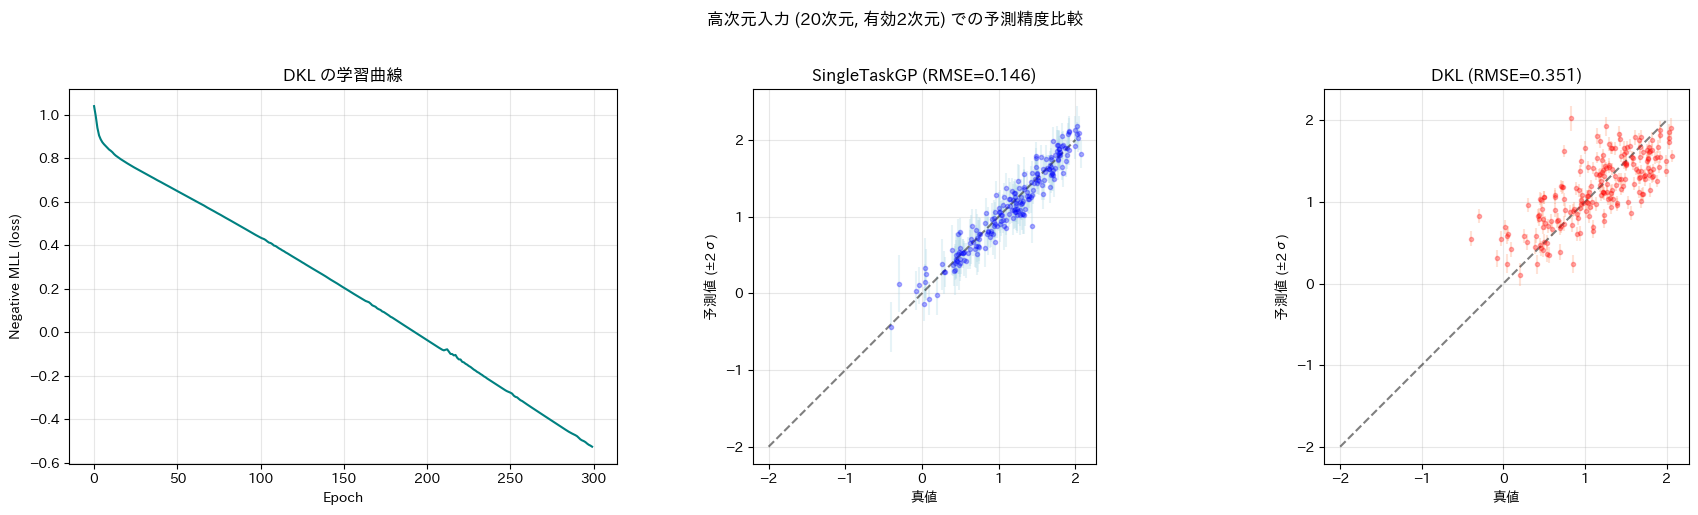

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左: 学習曲線
axes[0].plot(losses, color="teal")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Negative MLL (loss)")
axes[0].set_title("DKL の学習曲線")
axes[0].grid(alpha=0.3)

# 中: SingleTaskGP の予測 vs 真値
axes[1].errorbar(Y_test.numpy(), gp_mean.numpy(), yerr=2*gp_std.numpy(),
                 fmt="o", alpha=0.3, markersize=3, color="blue", ecolor="lightblue")
axes[1].plot([-2, 2], [-2, 2], "k--", alpha=0.5)
axes[1].set_xlabel("真値")
axes[1].set_ylabel("予測値 (±2σ)")
axes[1].set_title(f"SingleTaskGP (RMSE={gp_rmse:.3f})")
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.3)

# 右: DKL の予測 vs 真値
axes[2].errorbar(Y_test.numpy(), dkl_mean.numpy(), yerr=2*dkl_std.numpy(),
                 fmt="o", alpha=0.3, markersize=3, color="red", ecolor="lightsalmon")
axes[2].plot([-2, 2], [-2, 2], "k--", alpha=0.5)
axes[2].set_xlabel("真値")
axes[2].set_ylabel("予測値 (±2σ)")
axes[2].set_title(f"DKL (RMSE={dkl_rmse:.3f})")
axes[2].set_aspect("equal")
axes[2].grid(alpha=0.3)

plt.suptitle("高次元入力 (20次元, 有効2次元) での予測精度比較", y=1.02)
plt.tight_layout()
plt.show()

## 3. DKL を MOBO に組み込む

Step 2 の `SingleTaskGP` を DKL に置き換えて BraninCurrin で MOBO を回す。

多目的の場合、**目的ごとに独立した DKL モデル**を作り、`ModelList` でまとめる。

In [8]:
problem = BraninCurrin(negate=True)
bounds = problem.bounds.to(dtype=dtype)
ref_point = torch.tensor([-18.0, -6.0], dtype=dtype)
hv = Hypervolume(ref_point=ref_point)

def run_mobo_dkl(problem, bounds, ref_point, n_initial=10, n_iterations=30,
                 hidden_dim=32, feature_dim=4, n_epochs=200, seed=0):
    """DKL を使った MOBO ループ"""
    torch.manual_seed(seed)

    train_X = draw_sobol_samples(bounds=bounds, n=n_initial, q=1, seed=seed).squeeze(1)
    train_Y = problem(train_X)

    hv = Hypervolume(ref_point=ref_point)
    history = []

    pareto_mask = is_non_dominated(train_Y)
    initial_hv = hv.compute(train_Y[pareto_mask])
    history.append({"iteration": 0, "hv": initial_hv, "n_pareto": pareto_mask.sum().item()})
    print(f"  初期: {n_initial}点, HV={initial_hv:.4f}")

    for i in range(n_iterations):
        # 目的ごとに DKL モデルを作成・学習
        models = []
        for obj_idx in range(train_Y.shape[1]):
            model, lik = create_dkl(
                train_X, train_Y[:, obj_idx],
                input_dim=train_X.shape[1],
                hidden_dim=hidden_dim, feature_dim=feature_dim
            )
            train_dkl(model, lik, train_X, train_Y[:, obj_idx], n_epochs=n_epochs, lr=0.01)
            models.append(model)

        model_list = ModelList(*models)

        # qLogNEHVI
        acqf = qLogNoisyExpectedHypervolumeImprovement(
            model=model_list,
            ref_point=ref_point.tolist(),
            X_baseline=train_X,
        )

        candidate, _ = optimize_acqf(
            acq_function=acqf,
            bounds=bounds,
            q=1,
            num_restarts=8,
            raw_samples=64,
        )

        new_Y = problem(candidate)
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, new_Y])

        pareto_mask = is_non_dominated(train_Y)
        current_hv = hv.compute(train_Y[pareto_mask])
        history.append({"iteration": i + 1, "hv": current_hv, "n_pareto": pareto_mask.sum().item()})

        if (i + 1) % 5 == 0:
            print(f"  iter {i+1:2d}: PF={pareto_mask.sum().item()}点, HV={current_hv:.4f}")

    return train_X, train_Y, history

print("DKL-MOBO ループ開始 (30 iterations)...")
train_X_dkl, train_Y_dkl, history_dkl = run_mobo_dkl(problem, bounds, ref_point)
print(f"\n最終結果: HV={history_dkl[-1]['hv']:.4f}")

DKL-MOBO ループ開始 (30 iterations)...
  初期: 10点, HV=0.0000


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.mini

  iter  5: PF=10点, HV=0.0000


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message AB

  iter 10: PF=15点, HV=0.0000


...

  iter 20: PF=5点, HV=45.5230


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the d

  iter 25: PF=9点, HV=50.6225


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the d

  iter 30: PF=12点, HV=52.1503

最終結果: HV=52.1503


In [9]:
# Step 2 の SingleTaskGP-MOBO も同条件で実行して比較
def run_mobo_gp(problem, bounds, ref_point, n_initial=10, n_iterations=30, seed=0):
    """SingleTaskGP を使った MOBO ループ（Step 2 と同じ）"""
    torch.manual_seed(seed)
    train_X = draw_sobol_samples(bounds=bounds, n=n_initial, q=1, seed=seed).squeeze(1)
    train_Y = problem(train_X)
    hv = Hypervolume(ref_point=ref_point)
    history = []

    pareto_mask = is_non_dominated(train_Y)
    history.append({"iteration": 0, "hv": hv.compute(train_Y[pareto_mask])})

    for i in range(n_iterations):
        model = SingleTaskGP(train_X, train_Y)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        acqf = qLogNoisyExpectedHypervolumeImprovement(
            model=model, ref_point=ref_point.tolist(), X_baseline=train_X,
        )
        candidate, _ = optimize_acqf(acq_function=acqf, bounds=bounds, q=1,
                                      num_restarts=8, raw_samples=64)
        new_Y = problem(candidate)
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, new_Y])
        pareto_mask = is_non_dominated(train_Y)
        history.append({"iteration": i + 1, "hv": hv.compute(train_Y[pareto_mask])})

    return train_X, train_Y, history

print("SingleTaskGP-MOBO (比較用) 実行中...")
train_X_gp, train_Y_gp, history_gp = run_mobo_gp(problem, bounds, ref_point)
print(f"完了: HV={history_gp[-1]['hv']:.4f}")

SingleTaskGP-MOBO (比較用) 実行中...


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[NumericalWarning('A not p.d., added jitter of 1.0e-08 to the diagonal'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: 

完了: HV=57.2956


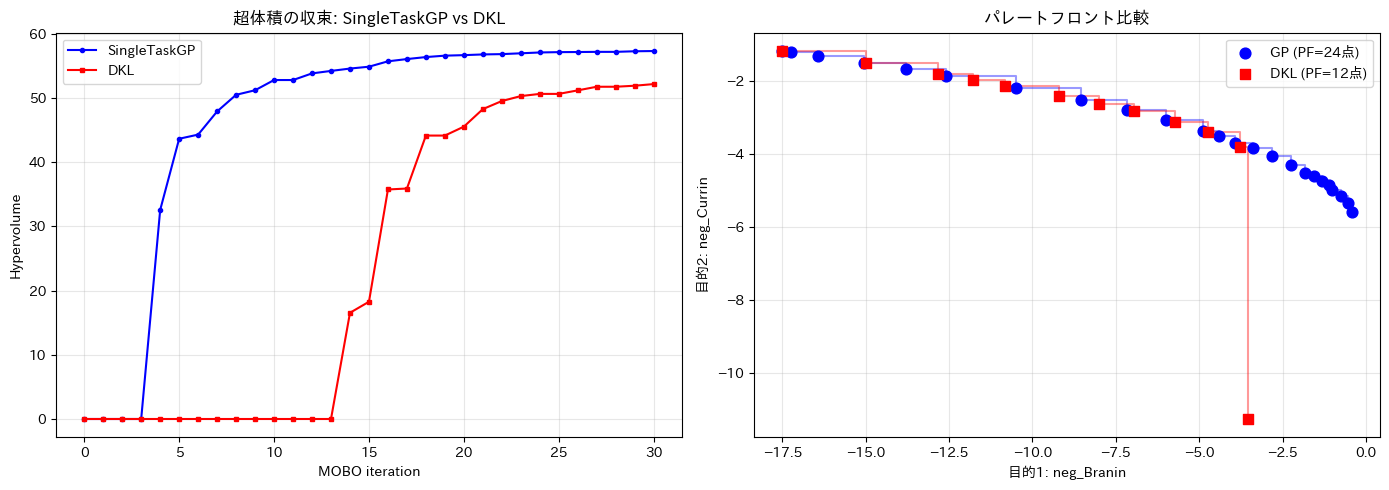

BraninCurrin (2次元入力) では GP と DKL の差は小さい。
DKL の真価は Step 2 の比較で見たような高次元入力で発揮される。


In [10]:
# SingleTaskGP vs DKL の比較プロット
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: 超体積の収束比較
iters_gp = [h["iteration"] for h in history_gp]
hvs_gp = [h["hv"] for h in history_gp]
iters_dkl = [h["iteration"] for h in history_dkl]
hvs_dkl = [h["hv"] for h in history_dkl]

ax1.plot(iters_gp, hvs_gp, "o-", color="blue", markersize=3, label="SingleTaskGP")
ax1.plot(iters_dkl, hvs_dkl, "s-", color="red", markersize=3, label="DKL")
ax1.set_xlabel("MOBO iteration")
ax1.set_ylabel("Hypervolume")
ax1.set_title("超体積の収束: SingleTaskGP vs DKL")
ax1.legend()
ax1.grid(alpha=0.3)

# 右: パレートフロント比較
pareto_gp = is_non_dominated(train_Y_gp)
pareto_dkl = is_non_dominated(train_Y_dkl)

ax2.scatter(train_Y_gp[pareto_gp, 0], train_Y_gp[pareto_gp, 1],
            c="blue", s=60, label=f"GP (PF={pareto_gp.sum().item()}点)", zorder=4)
ax2.scatter(train_Y_dkl[pareto_dkl, 0], train_Y_dkl[pareto_dkl, 1],
            c="red", s=60, marker="s", label=f"DKL (PF={pareto_dkl.sum().item()}点)", zorder=5)

pf_gp = train_Y_gp[pareto_gp].numpy()
pf_gp = pf_gp[pf_gp[:, 0].argsort()]
ax2.step(pf_gp[:, 0], pf_gp[:, 1], "b-", where="post", alpha=0.4)

pf_dkl = train_Y_dkl[pareto_dkl].numpy()
pf_dkl = pf_dkl[pf_dkl[:, 0].argsort()]
ax2.step(pf_dkl[:, 0], pf_dkl[:, 1], "r-", where="post", alpha=0.4)

ax2.set_xlabel("目的1: neg_Branin")
ax2.set_ylabel("目的2: neg_Currin")
ax2.set_title("パレートフロント比較")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"BraninCurrin (2次元入力) では GP と DKL の差は小さい。")
print(f"DKL の真価は Step 2 の比較で見たような高次元入力で発揮される。")

## まとめ

### DKL の位置づけ

| | SingleTaskGP | DKL |
|---|---|---|
| **入力次元** | 低次元 (〜10) に強い | 高次元 (数百) に対応 |
| **モデル構造** | カーネル関数のみ | MLP + カーネル関数 |
| **学習方法** | `fit_gpytorch_mll` (L-BFGS) | Adam で NN + GP を同時最適化 |
| **パラメータ数** | 数個（ハイパラのみ） | 数百〜数千（NN の重み + ハイパラ） |
| **不確実性** | 正確 | GP 部分が提供（NN は点推定） |
| **いつ使う** | 低次元・データ少量 | 高次元・特徴抽出が必要 |

### 論文との対応

| この notebook | 論文 |
|---|---|
| `FeatureExtractor` (MLP) | 分子記述子 → 低次元特徴量への変換 |
| `DKLModel` | TC / Bulk Modulus それぞれの DKL サロゲート |
| `ModelList` で2目的 | 目的ごとに独立した DKL モデル |

### Step 4 への接続

- テスト関数 → **実データ**（公開ポリマーデータ等）
- AL ループの完成形: DKL + qLogNEHVI + パレートフロント可視化
- 解釈性分析（どの記述子が効いているか）